# Credit Card Fraud

Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


## EDA Roadmap for Credit Card Fraud Detection Dataset

The dataset contains:

* **284,807 transactions**
* **30 input features**: `Time`, `Amount`, `V1` to `V28`
* **Target**: `Class` (`0 = Normal`, `1 = Fraud`)

---

# 1. Basic Dataset Inspection


# 2. Target Variable Analysis (Most Important)

### Question
* Is target imbalanced


# 3. Analyze `Amount`

### Questions

* Are fraudulent transactions generally larger or smaller?
* What are the median and quartiles?

# 4. Analyze `Time`

### Questions

* Does fraud occur more frequently at certain times?


# 5. Feature Distributions (`V1`–`V28`)

These are PCA-transformed variables.

### Recommended Features to Visualize

Start with:

* `V1`
* `V2`
* `V3`
* `V4`
* `V10`
* `V12`
* `V14`
* `V17`

These often show strong separation.

---

# 6. Correlation Analysis

### Goals

Identify features most associated with fraud.

# 7. Outlier Analysis

### Tasks

* Use boxplots.
* Compare distributions between classes.

Note: Outliers may represent fraud and should not be removed blindly.

---

# 8. Dimensionality Reduction Visualization


### Methods

* PCA
* t-SNE

### Goal

Visualize whether fraud transactions form clusters.

---


In [9]:
import pandas as pd

import matplotlib.pyplot as plt

# 1. BASIC DATASET INSPECTION

In [3]:
# Load the dataset
df = pd.read_csv("temp/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
# First 5 Rows
print("\nFirst 5 Rows:")
print(df.head())


In [4]:
# Dataset Shape
print("Dataset Shape (rows, columns):")
print(df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns.tolist())


Dataset Shape (rows, columns):
(284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
# Data Types and Non-Null Counts
print("\nDataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [6]:
# Summary Statistics for Numerical Columns
print("\nSummary Statistics:")
print(df.describe())



Summary Statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  

In [7]:
# Missing Values per Column
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Total Missing Values
print("\nTotal Missing Values in Dataset:")
print(df.isnull().sum().sum())



Missing Values per Column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing Values in Dataset:
0


# CHECK FOR DUPLICATE ROWS

In [8]:
# Number of duplicate rows
num_duplicates = df.duplicated().sum()

print("Number of duplicate rows:", num_duplicates)

# Display duplicate rows
if num_duplicates > 0:
    print("\nDuplicate Rows:")
    print(df[df.duplicated()])
else:
    print("\nNo duplicate rows found.")


# REMOVE DUPLICATE ROWS
# Keep the first occurrence and remove the rest
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

# Verify duplicates are removed
print("Remaining duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1081

Duplicate Rows:
            Time        V1        V2        V3        V4        V5        V6  \
33          26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
35          26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
113         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115         74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
...          ...       ...       ...       ...       ...       ...       ...   
282987  171288.0  1.912550 -0.455240 -1.750654  0.454324  2.089130  4.160019   
283483  171627.0 -1.464380  1.368119  0.815992 -0.601282 -0.689115 -0.487154   
283485  171627.0 -1.457978  1.378203  0.811515 -0.603760 -0.711883 -0.471672   
284191  172233.0 -2.667936  3.160505 -3.355984  1.007845 -0.377397 -0.109730   
284193  172233.0 -2.691642  3.123168 -3.339407  1.017018 -0.293095 -0.16

# 2. TARGET VARIABLE ANALYSIS

Class Counts:
Class
0    283253
1       473
Name: count, dtype: int64

Class Percentages:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Fraud Rate: 0.1667%


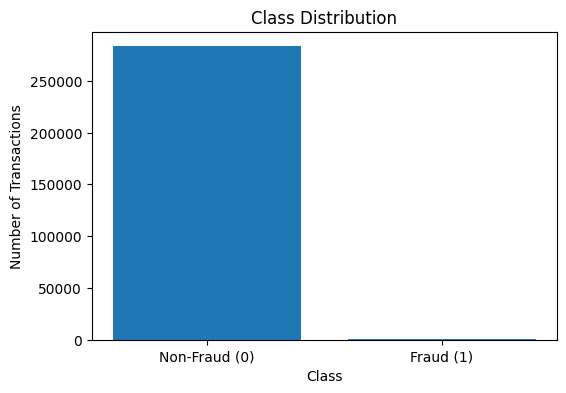

In [12]:
# Count of Each Class
class_counts = df['Class'].value_counts().sort_index()

print("Class Counts:")
print(class_counts)

# Percentage Distribution
class_percentages = df['Class'].value_counts(normalize=True).sort_index() * 100

print("\nClass Percentages:")
print(class_percentages)

# Fraud Rate
fraud_rate = class_percentages[1]
print(f"\nFraud Rate: {fraud_rate:.4f}%")

# More Readable Labels
labels = ['Non-Fraud (0)', 'Fraud (1)']

# Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(labels, class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.xlabel("Class")
plt.show()


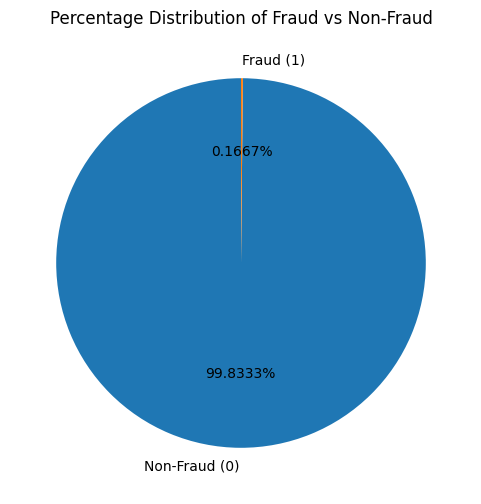

In [13]:
# Pie Chart (Optional)
plt.figure(figsize=(6, 6))
plt.pie(
    class_counts.values,
    labels=labels,
    autopct='%1.4f%%',
    startangle=90
)
plt.title("Percentage Distribution of Fraud vs Non-Fraud")
plt.show()

### Key Insight

Fraud cases are extremely rare (~0.17%).



# 3. Analyze `Amount`


In [14]:
# Summary statistics for Amount by Class

amount_stats = df.groupby('Class')['Amount'].describe()
print(amount_stats)

# Observ: Mean for fraud is larger than non-fraud

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [15]:
# Median Comparison
print(df.groupby('Class')['Amount'].median())

Class
0    22.00
1     9.82
Name: Amount, dtype: float64


### Interpretation:

- If fraud median < non-fraud median, fraudulent transactions are generally smaller.
- If fraud median > non-fraud median, fraudulent transactions are generally larger.

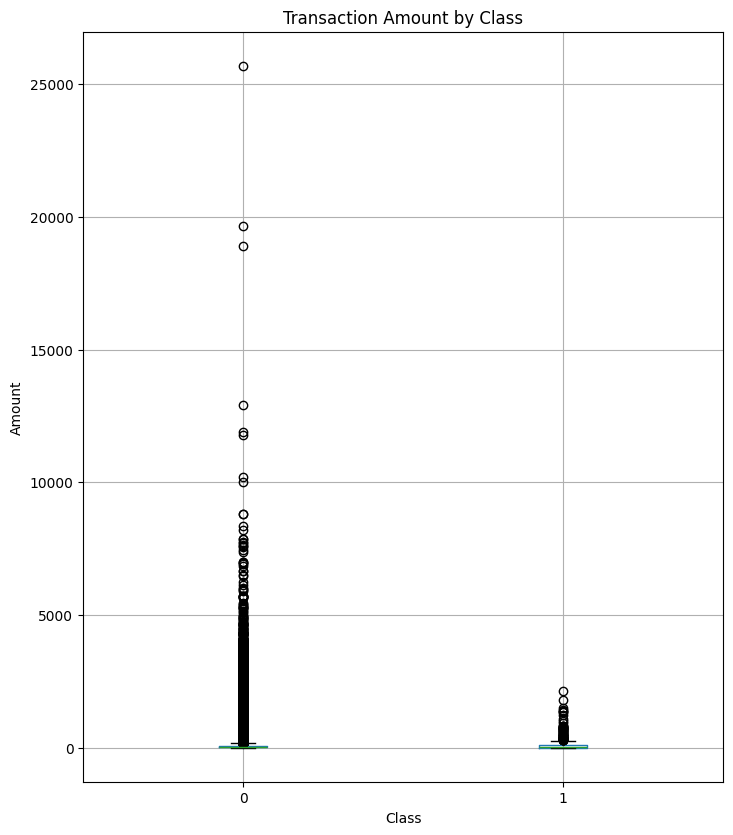

In [17]:
# Boxplot by Class
import matplotlib.pyplot as plt

df.boxplot(column='Amount', by='Class', figsize=(8, 10))
plt.title("Transaction Amount by Class")
plt.suptitle("")
plt.ylabel("Amount")
plt.show()

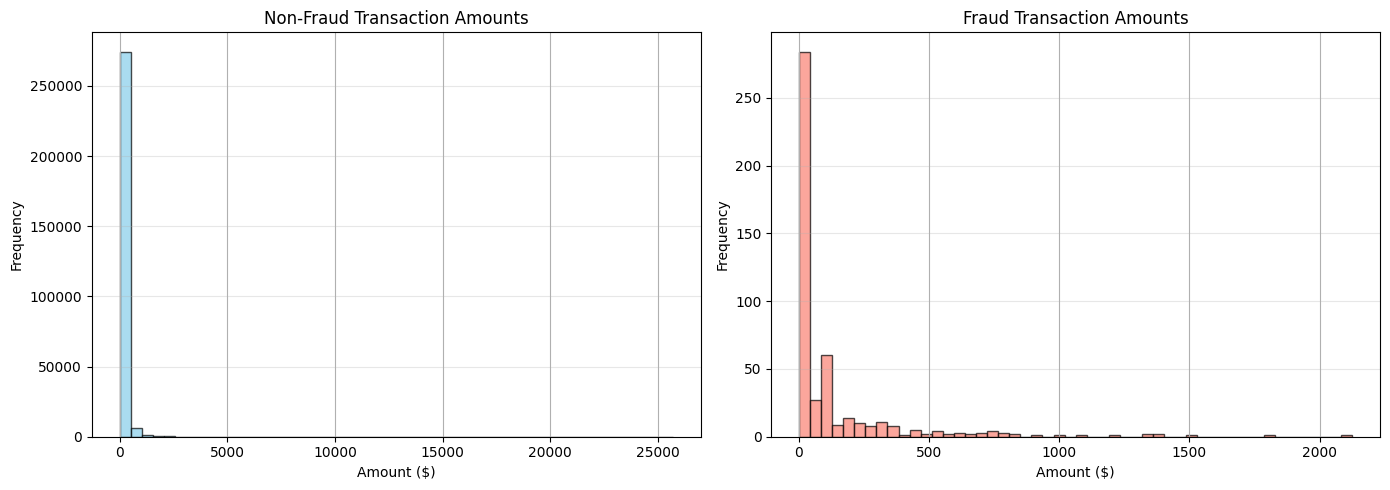

In [19]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Plot Non-Fraud Transactions
df[df['Class'] == 0]['Amount'].hist(
    bins=50, ax=axes[0], color='skyblue', edgecolor='black', alpha=0.7
)
axes[0].set_title('Non-Fraud Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Plot Fraud Transactions
df[df['Class'] == 1]['Amount'].hist(
    bins=50, ax=axes[1], color='salmon', edgecolor='black', alpha=0.7
)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [23]:
# Log Transformation
import numpy as np

df['LogAmount'] = np.log1p(df['Amount'])

C:\Users\hi\AppData\Local\Temp\ipykernel_444\1808265476.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LogAmount'] = np.log1p(df['Amount'])


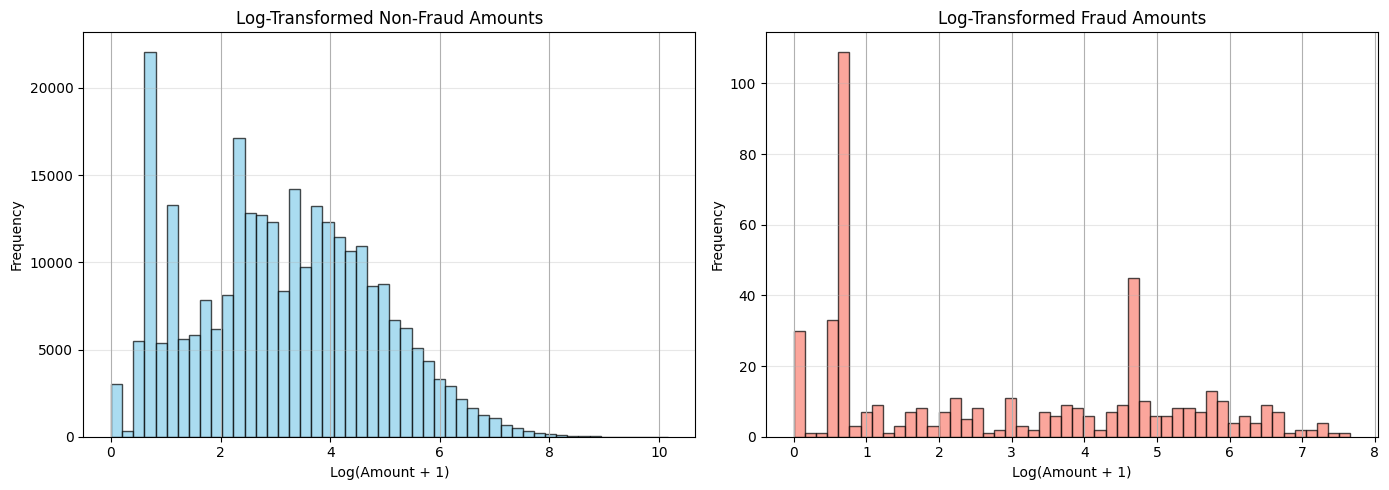

In [22]:
import matplotlib.pyplot as plt

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Plot Log Non-Fraud Transactions
df[df['Class'] == 0]['LogAmount'].hist(
    bins=50, ax=axes[0], color='skyblue', edgecolor='black', alpha=0.7
)
axes[0].set_title('Log-Transformed Non-Fraud Amounts')
axes[0].set_xlabel('Log(Amount + 1)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Plot Log Fraud Transactions
df[df['Class'] == 1]['LogAmount'].hist(
    bins=50, ax=axes[1], color='salmon', edgecolor='black', alpha=0.7
)
axes[1].set_title('Log-Transformed Fraud Amounts')
axes[1].set_xlabel('Log(Amount + 1)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


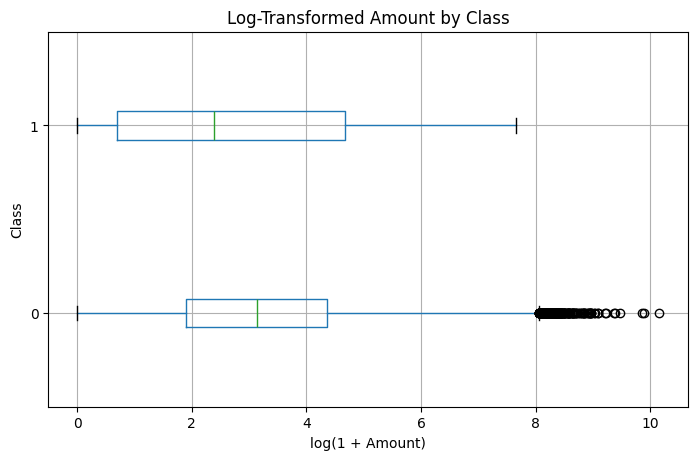

In [25]:
# Horizontal Boxplot
df.boxplot(column='LogAmount', by='Class', figsize=(8, 5), vert=False)
plt.title("Log-Transformed Amount by Class")
plt.suptitle("")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Class")
plt.show()


# 4. ANALYZE TIME FEATURE

In [26]:
# Basic Statistics for Time
print(df['Time'].describe())


count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64


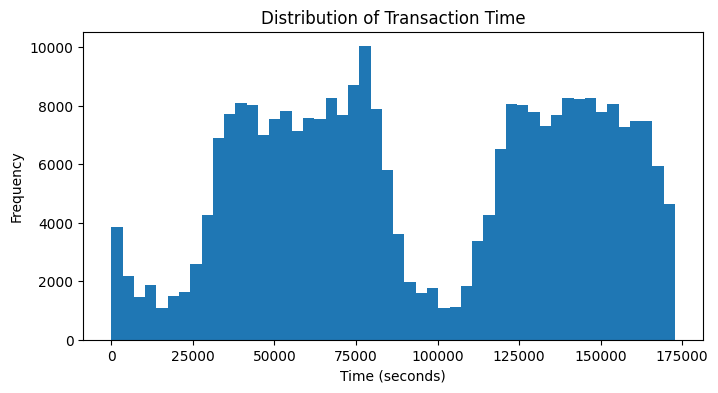

In [29]:
# HISTOGRAM OF TIME
# Time is measured in seconds from the
# first transaction in the dataset.

plt.figure(figsize=(8, 4))
plt.hist(df['Time'], bins=50)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_444\3173477722.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df['Time'] / 3600



First 5 Hour Values:
0    0.000000
1    0.000000
2    0.000278
3    0.000278
4    0.000556
Name: Hour, dtype: float64


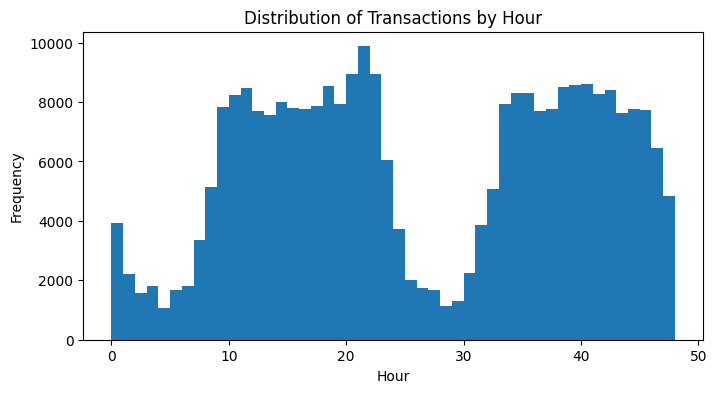

In [30]:
# CONVERT SECONDS TO HOURS
# Convert Time from seconds to hours

df['Hour'] = df['Time'] / 3600

print("\nFirst 5 Hour Values:")
print(df['Hour'].head())


# HISTOGRAM OF HOURS
plt.figure(figsize=(8, 4))
plt.hist(df['Hour'], bins=48)
plt.title("Distribution of Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()

# Important

**Transactions are distributed over roughly 48 hours.**

The Time feature is:

- Relative time from the first transaction.
- Not actual clock timestamps.

So patterns indicate temporal behavior, but not exact real-world hours like “2 PM” or “midnight”.



Fraud Count by Hour:
Hour
0      2
1      2
2     21
3     13
4      6
5     11
6      3
7     23
8      5
9     15
10     2
11    43
12     9
13     9
14    13
15    14
16    14
17    12
18    10
19     7
20     8
21    14
22     3
23    13
24     4
25     8
26    27
27     4
28    17
30     6
32     4
33     1
34     6
35    10
36     8
37     8
38    10
39    12
40     8
41    16
42    18
43    12
44    10
45     2
46     6
47     4
dtype: int64


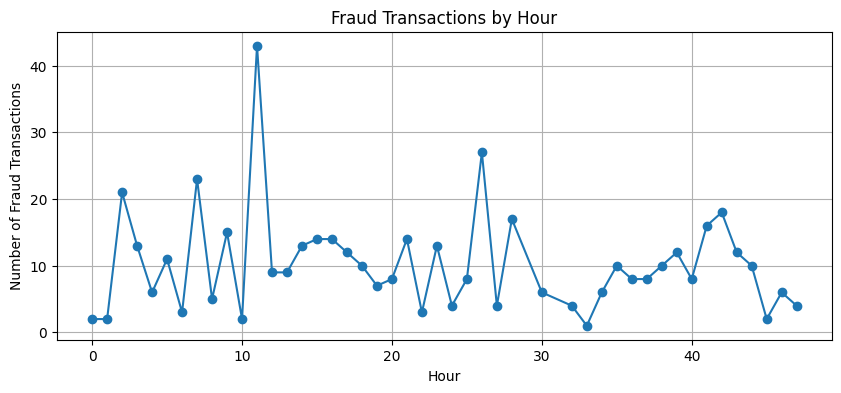

In [32]:
# FRAUD COUNT BY HOUR

# Separate fraud transactions
fraud_df = df[df['Class'] == 1]

# Count frauds by hour (rounded down)
fraud_by_hour = fraud_df.groupby(fraud_df['Hour'].astype(int)).size()

print("\nFraud Count by Hour:")
print(fraud_by_hour)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o')
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Fraud Transactions")
plt.grid(True)
plt.show()




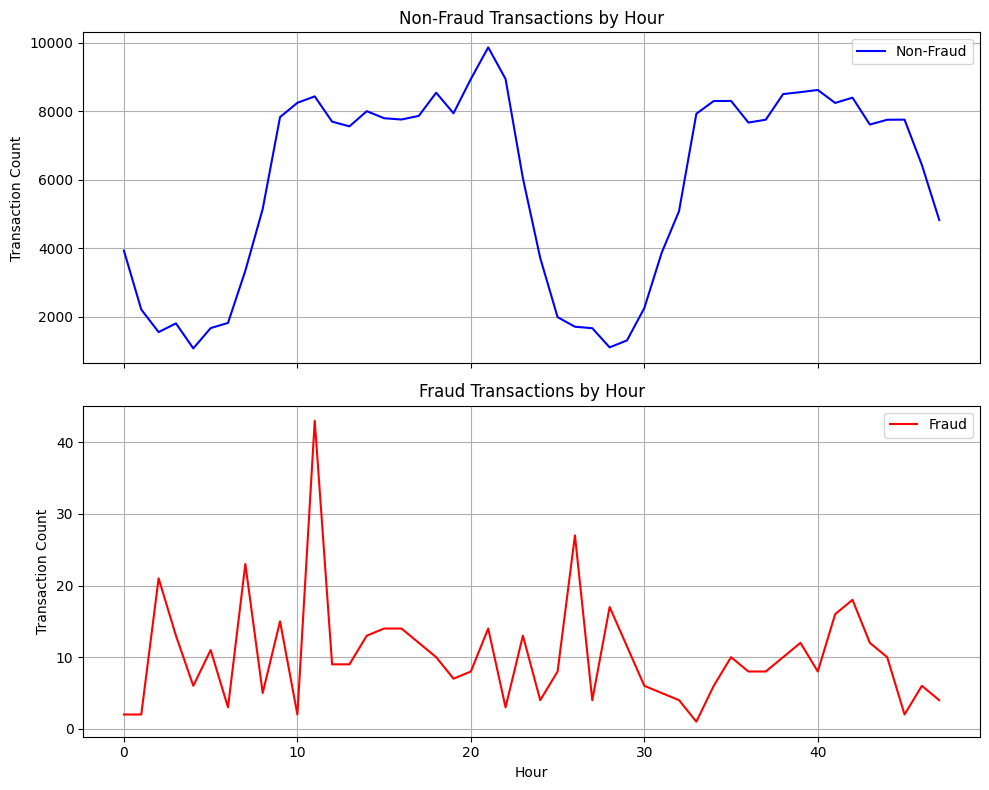

In [35]:
# (OPTIONAL:)
# Compare Fraud vs Non-Fraud by Hour

nonfraud_df = df[df['Class'] == 0]

nonfraud_by_hour = nonfraud_df.groupby(
    nonfraud_df['Hour'].astype(int)
).size()

# Separate Plots for Fraud vs Non-Fraud Transactions by Hour
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Non-Fraud
ax1.plot(
    nonfraud_by_hour.index,
    nonfraud_by_hour.values,
    color='blue',
    label='Non-Fraud'
)
ax1.set_title("Non-Fraud Transactions by Hour")
ax1.set_ylabel("Transaction Count")
ax1.grid(True)
ax1.legend()

# Plot 2: Fraud
ax2.plot(
    fraud_by_hour.index,
    fraud_by_hour.values,
    color='red',
    label='Fraud'
)
ax2.set_title("Fraud Transactions by Hour")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Transaction Count")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


# Observation
```
Transactions are distributed over roughly 48 hours.
Fraud does not occur uniformly over time.
Some hours show spikes in fraud activity.
Fraud counts are much smaller than non-fraud counts because of class imbalance.
```


Key Question to Ask Students

Are fraudsters operating continuously, or are there periods with increased fraud activity?

# 5. Feature Distributions (`V1`–`V28`)

In [37]:

# Features that often show strong separation
selected_features = [
    'V1', 'V2', 'V3', 'V4',
    'V10', 'V12', 'V14', 'V17'
]

# ------------------------------------------
# Summary Statistics by Class
# ------------------------------------------
for feature in selected_features:
    print("\n" + "=" * 60)
    print(f"SUMMARY STATISTICS FOR {feature}")
    print("=" * 60)
    print(df.groupby('Class')[feature].describe())


SUMMARY STATISTICS FOR V1
          count      mean       std       min       25%       50%       75%  \
Class                                                                         
0      283253.0  0.013439  1.922179 -56.40751 -0.913431  0.022562  1.316788   
1         473.0 -4.498280  6.593145 -30.55238 -5.603690 -2.271755 -0.361428   

            max  
Class            
0      2.454930  
1      2.132386  

SUMMARY STATISTICS FOR V2
          count      mean      std        min       25%       50%       75%  \
Class                                                                         
0      283253.0 -0.009829  1.63352 -72.715728 -0.601398  0.062561  0.797012   
1         473.0  3.405965  4.12250  -8.402154  1.145381  2.617105  4.571743   

             max  
Class             
0      18.902453  
1      22.057729  

SUMMARY STATISTICS FOR V3
          count      mean       std        min       25%       50%       75%  \
Class                                                    

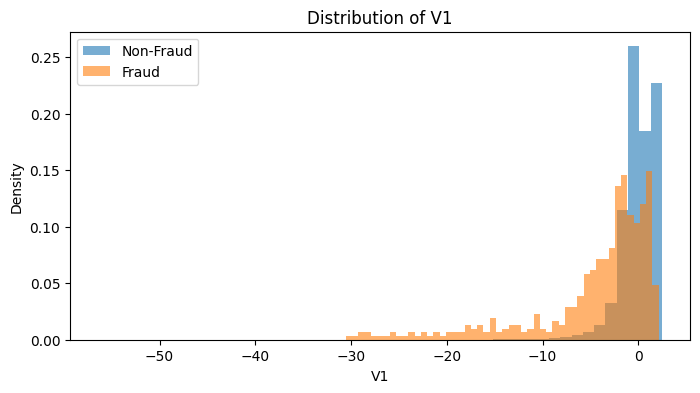

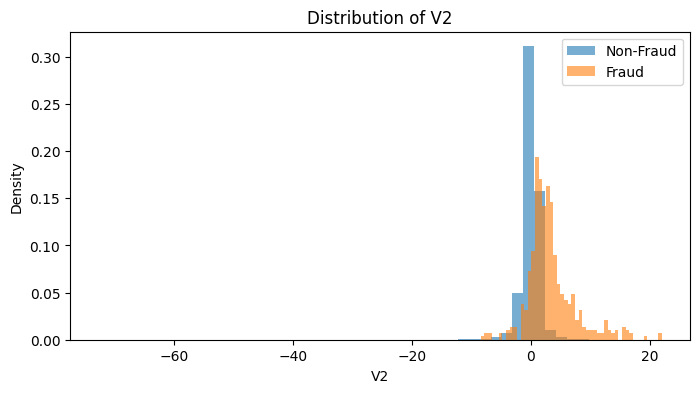

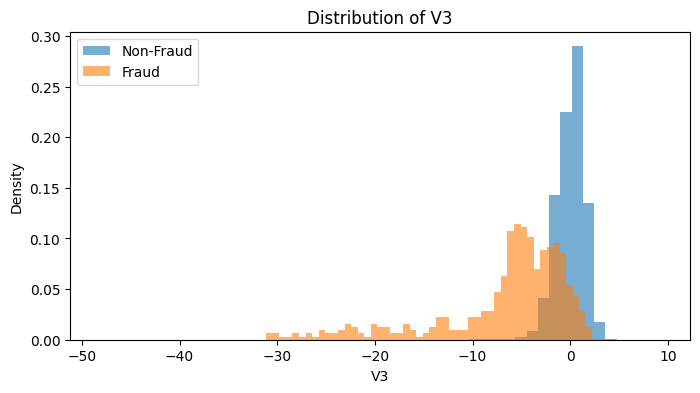

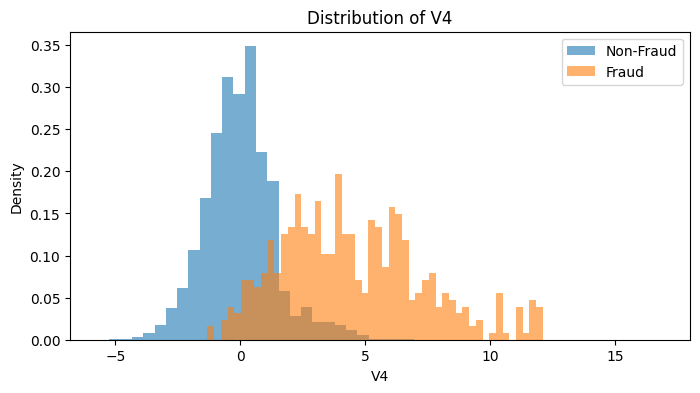

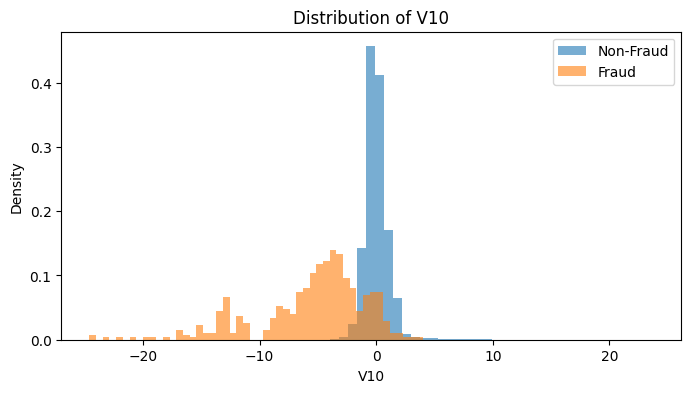

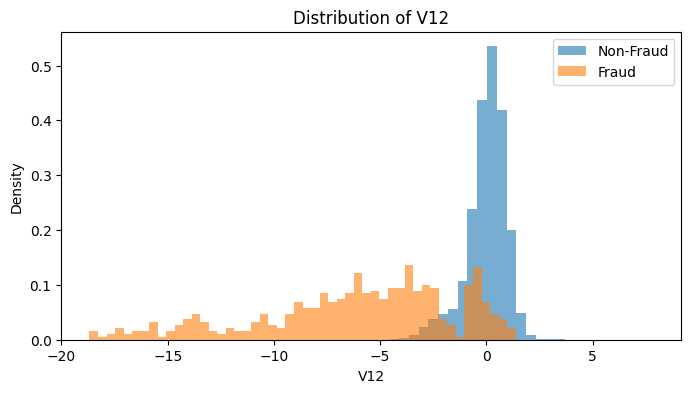

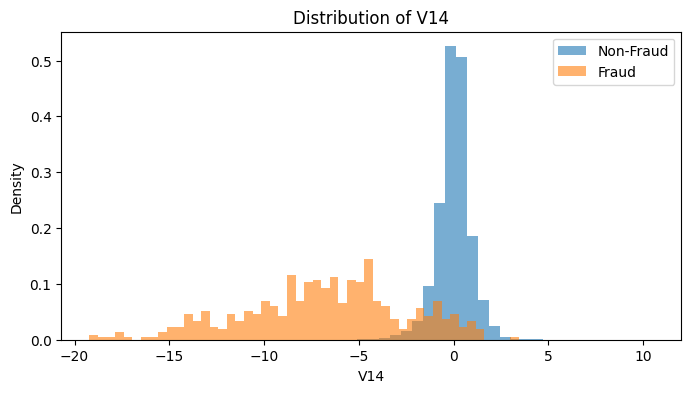

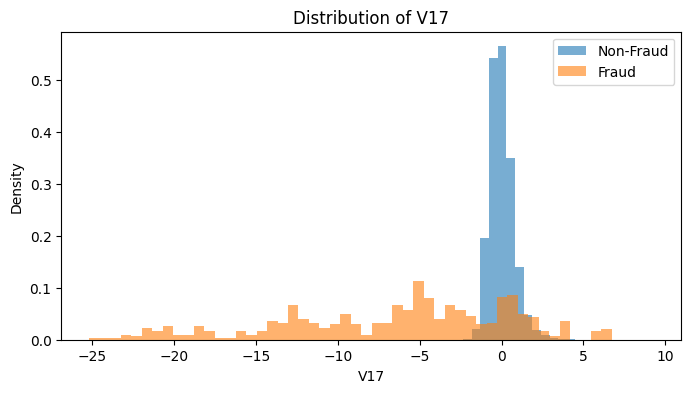

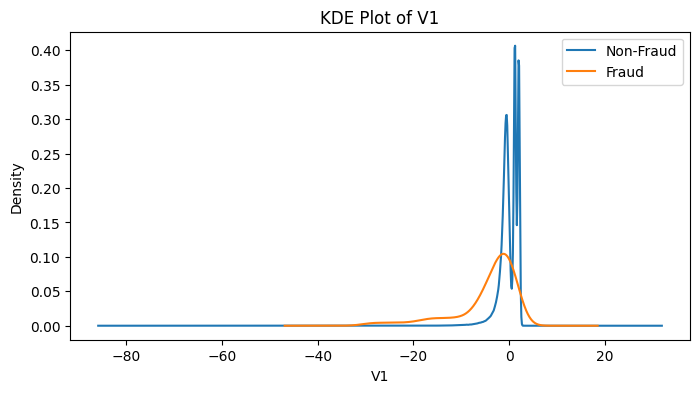

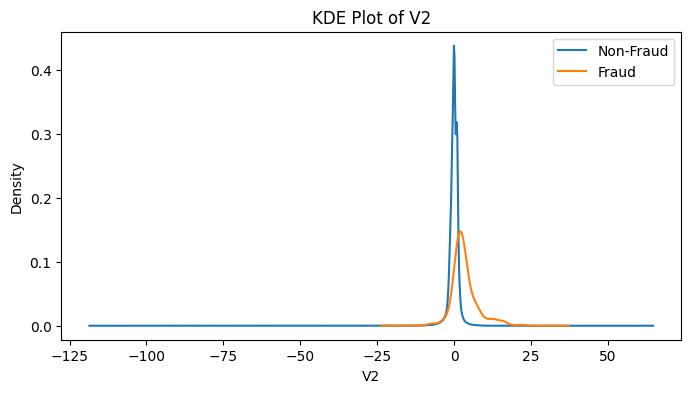

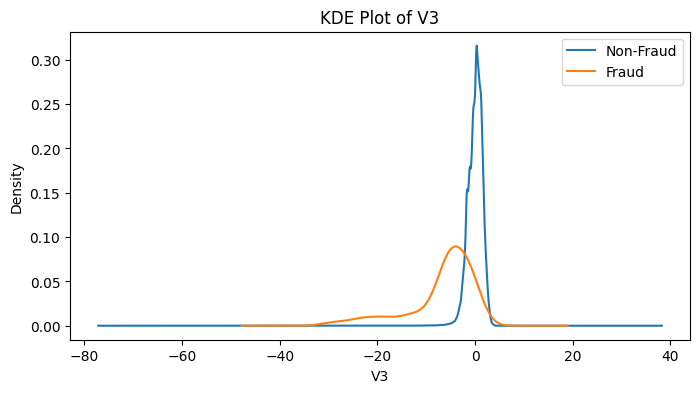

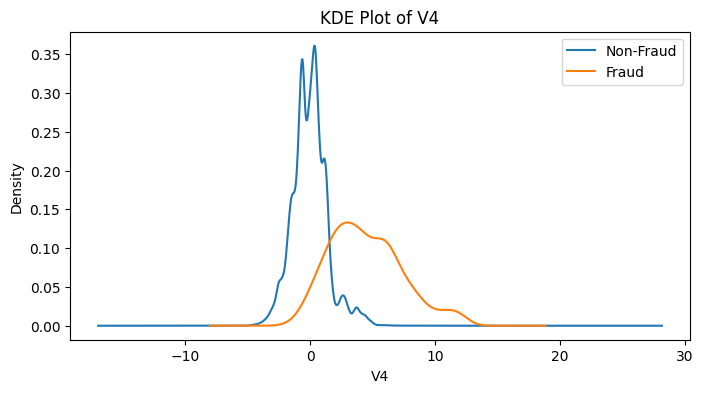

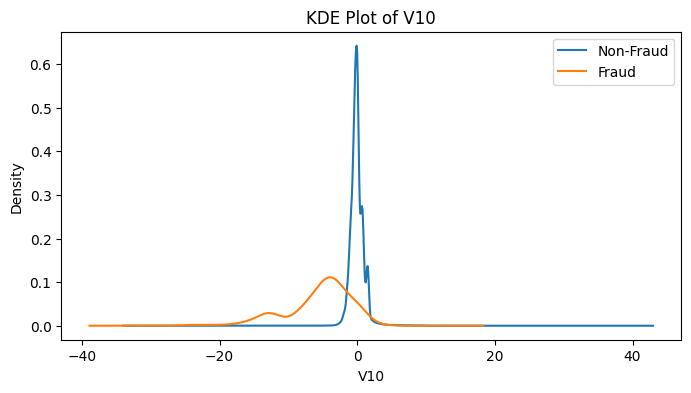

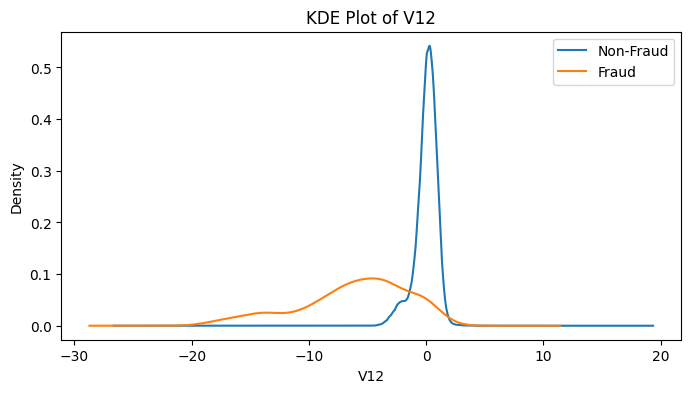

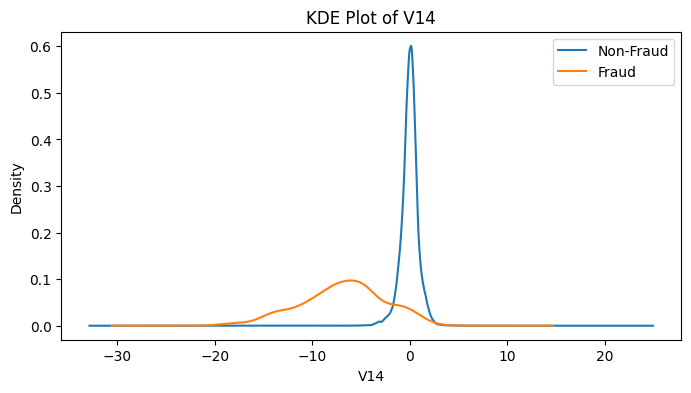

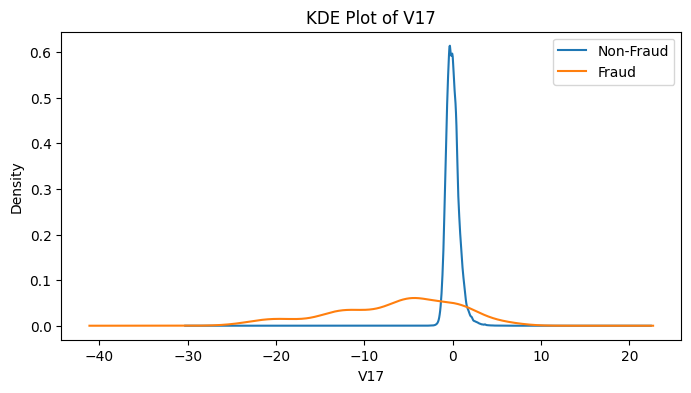

<Figure size 600x400 with 0 Axes>

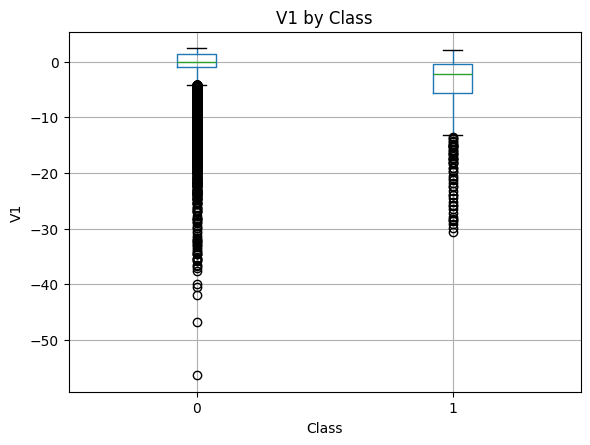

<Figure size 600x400 with 0 Axes>

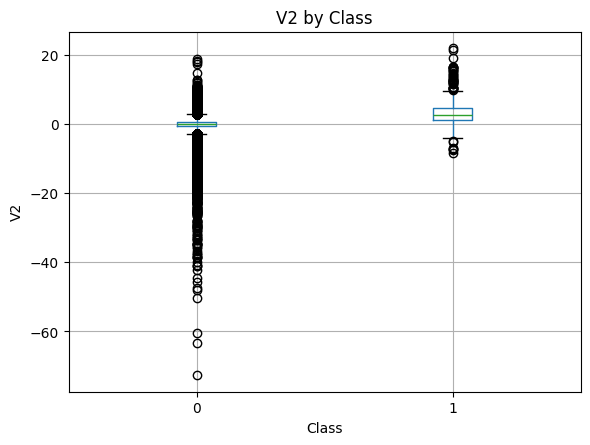

<Figure size 600x400 with 0 Axes>

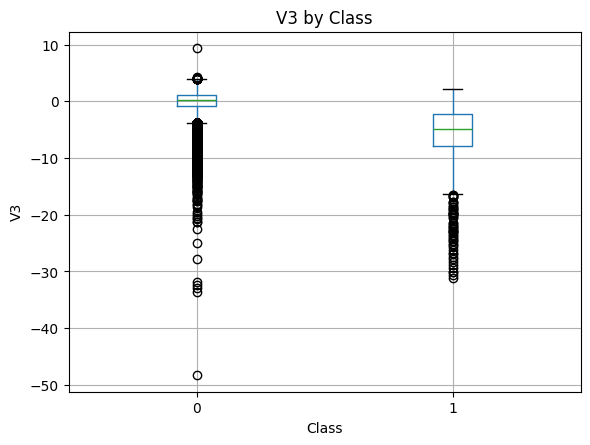

<Figure size 600x400 with 0 Axes>

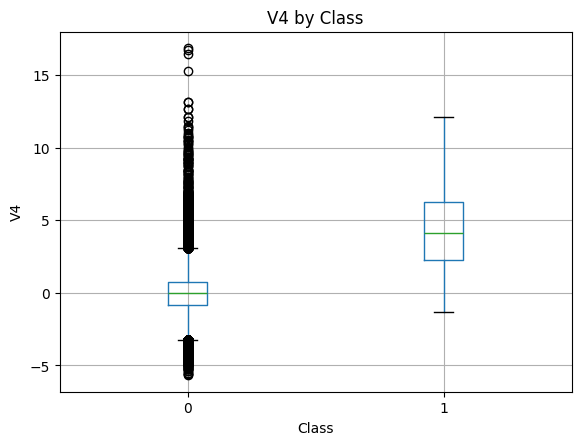

<Figure size 600x400 with 0 Axes>

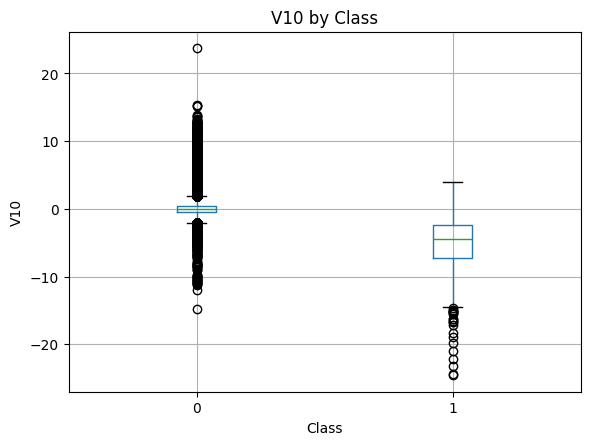

<Figure size 600x400 with 0 Axes>

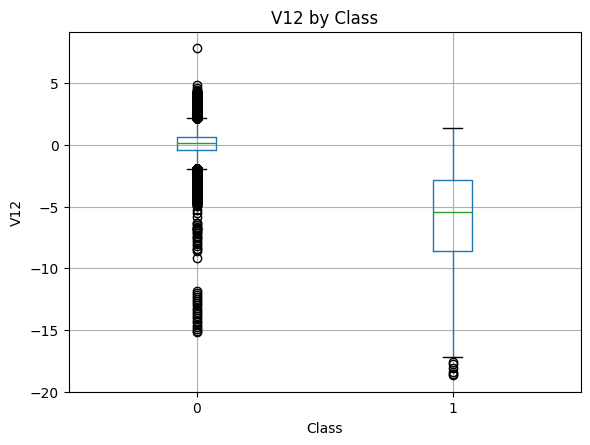

<Figure size 600x400 with 0 Axes>

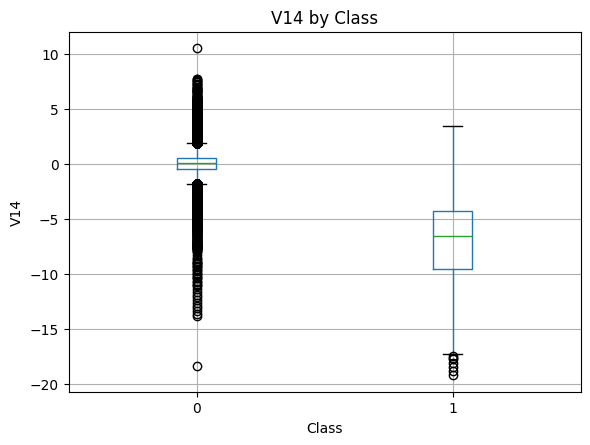

<Figure size 600x400 with 0 Axes>

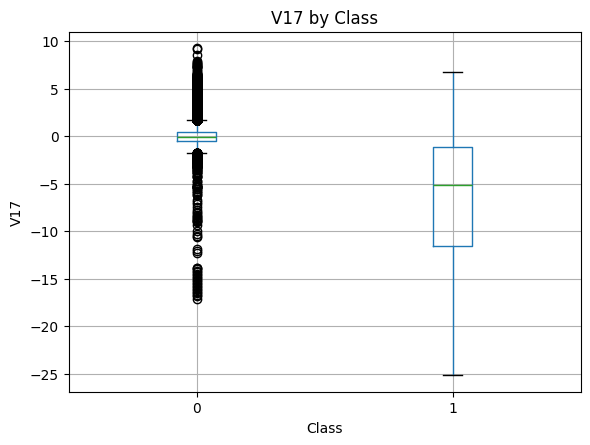

In [38]:
# HISTOGRAMS: FRAUD VS NON-FRAUD
for feature in selected_features:
    
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[df['Class'] == 0][feature],
        bins=50,
        alpha=0.6,
        density=True,
        label='Non-Fraud'
    )

    plt.hist(
        df[df['Class'] == 1][feature],
        bins=50,
        alpha=0.6,
        density=True,
        label='Fraud'
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


# KDE PLOTS: FRAUD VS NON-FRAUD
for feature in selected_features:

    plt.figure(figsize=(8, 4))

    df[df['Class'] == 0][feature].plot(
        kind='kde',
        label='Non-Fraud'
    )

    df[df['Class'] == 1][feature].plot(
        kind='kde',
        label='Fraud'
    )

    plt.title(f"KDE Plot of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


# BOXPLOTS BY CLASS
for feature in selected_features:

    plt.figure(figsize=(6, 4))

    df.boxplot(
        column=feature,
        by='Class'
    )

    plt.title(f"{feature} by Class")
    plt.suptitle("")  # remove default title
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.show()

# 6. Correlation Analysis

In [39]:

# Full Correlation Matrix
corr_matrix = df.corr()

print("Correlation Matrix Shape:")
print(corr_matrix.shape)


Correlation Matrix Shape:
(33, 33)


In [40]:
# Correlation of Each Feature with Class
class_corr = corr_matrix['Class'].drop('Class')

# Sort by absolute correlation
class_corr_sorted = class_corr.reindex(
    class_corr.abs().sort_values(ascending=False).index
)

print("\nCorrelation with Class (sorted by absolute value):")
print(class_corr_sorted)


Correlation with Class (sorted by absolute value):
V17         -0.313498
V14         -0.293375
V12         -0.250711
V10         -0.206971
V16         -0.187186
V3          -0.182322
V7          -0.172347
V11          0.149067
V4           0.129326
V18         -0.105340
V1          -0.094486
V9          -0.094021
V5          -0.087812
V2           0.084624
V6          -0.043915
V19          0.033631
V8           0.033068
V21          0.026357
V27          0.021892
V20          0.021486
Hour        -0.012359
Time        -0.012359
V28          0.009682
LogAmount   -0.007798
V24         -0.007210
V23         -0.006333
Amount       0.005777
V22          0.004887
V26          0.004265
V13         -0.003897
V15         -0.003300
V25          0.003202
Name: Class, dtype: float64



Top 10 Features Most Correlated with Fraud:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64


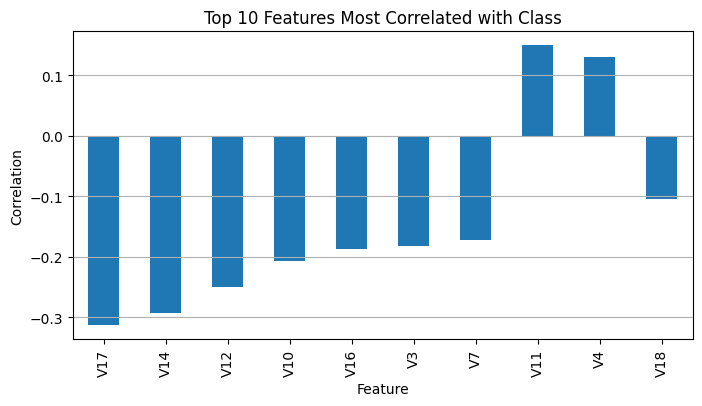

In [41]:
# Top 10 Most Correlated Features
top_10 = class_corr_sorted.head(10)

print("\nTop 10 Features Most Correlated with Fraud:")
print(top_10)

# Bar Chart of Top 10 Correlations
plt.figure(figsize=(8, 4))
top_10.plot(kind='bar')
plt.title("Top 10 Features Most Correlated with Class")
plt.ylabel("Correlation")
plt.xlabel("Feature")
plt.grid(axis='y')
plt.show()


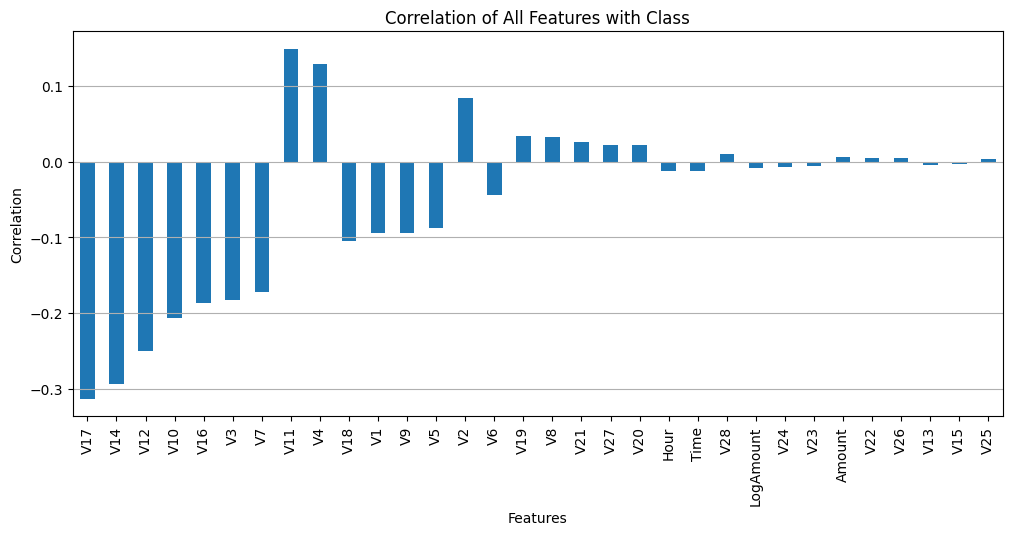

In [42]:
# Bar Chart of All Feature Correlations
plt.figure(figsize=(12, 5))
class_corr_sorted.plot(kind='bar')
plt.title("Correlation of All Features with Class")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.grid(axis='y')
plt.show()


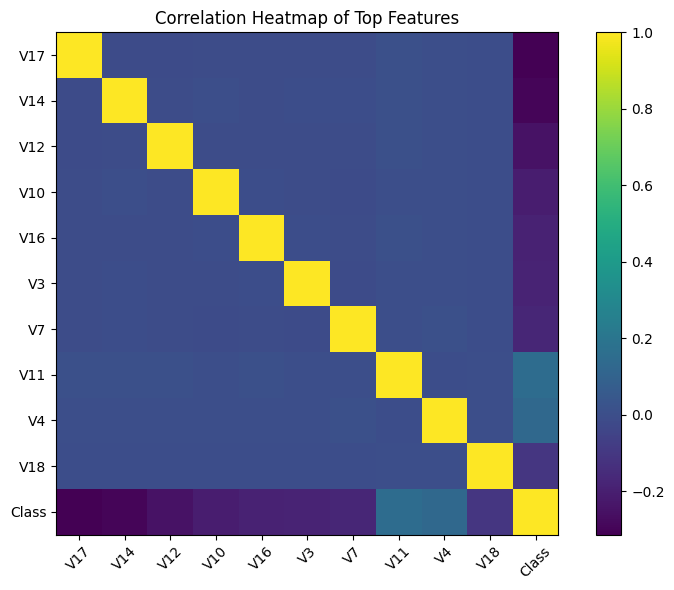

In [43]:
# Optional Heatmap of Top Correlated Features
# Select top correlated features plus target
top_features = list(top_10.index) + ['Class']

# Correlation matrix for top features
top_corr = df[top_features].corr()

# Plot heatmap using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(top_corr, interpolation='nearest')
plt.colorbar()

plt.xticks(
    range(len(top_corr.columns)),
    top_corr.columns,
    rotation=45
)

plt.yticks(
    range(len(top_corr.columns)),
    top_corr.columns
)

plt.title("Correlation Heatmap of Top Features")
plt.tight_layout()
plt.show()

# 7. OUTLIER ANALYSIS

<Figure size 600x400 with 0 Axes>

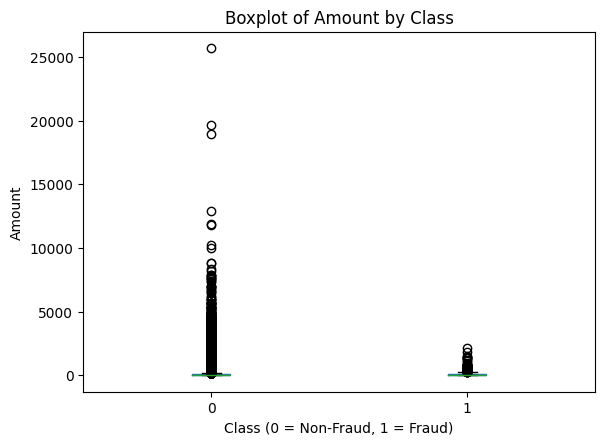

<Figure size 600x400 with 0 Axes>

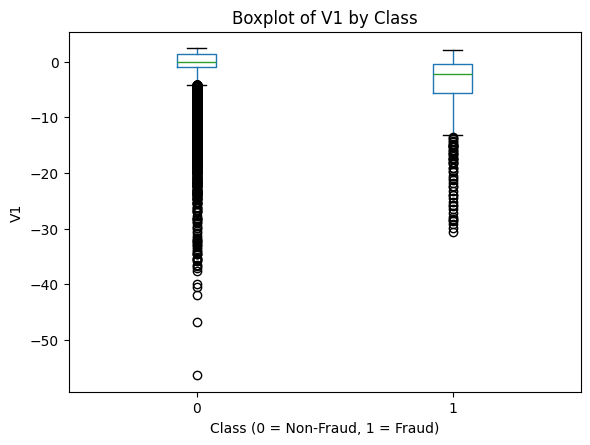

<Figure size 600x400 with 0 Axes>

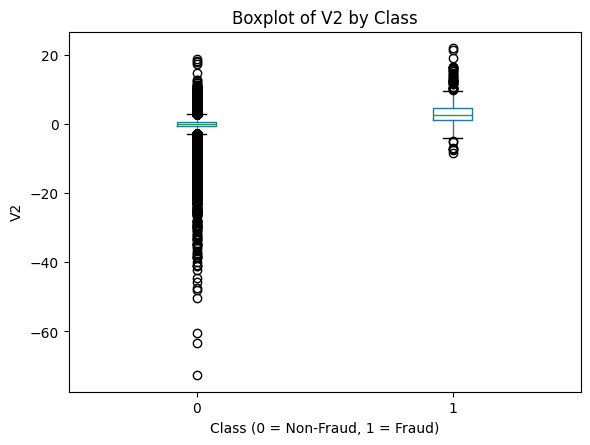

<Figure size 600x400 with 0 Axes>

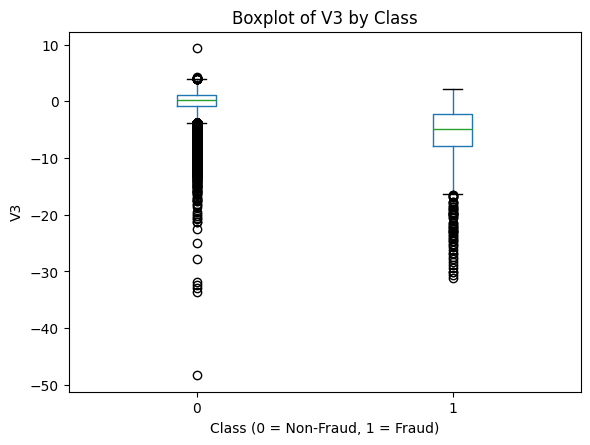

<Figure size 600x400 with 0 Axes>

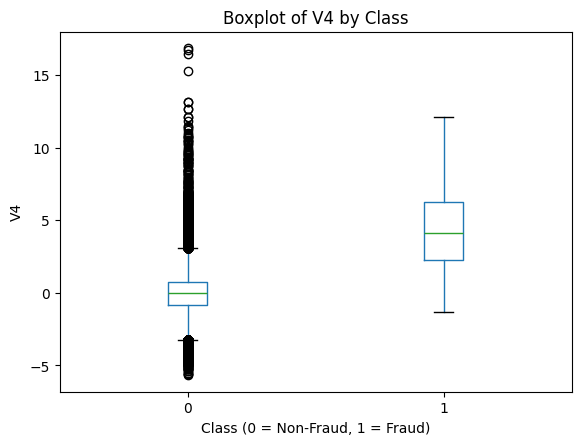

<Figure size 600x400 with 0 Axes>

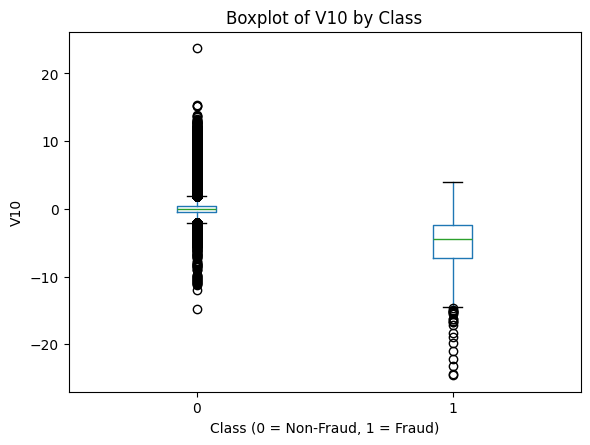

<Figure size 600x400 with 0 Axes>

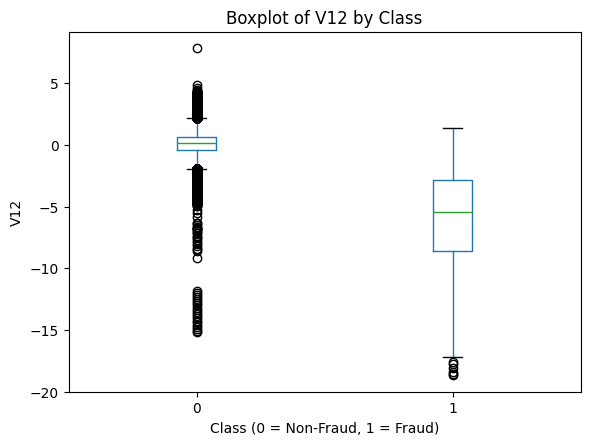

<Figure size 600x400 with 0 Axes>

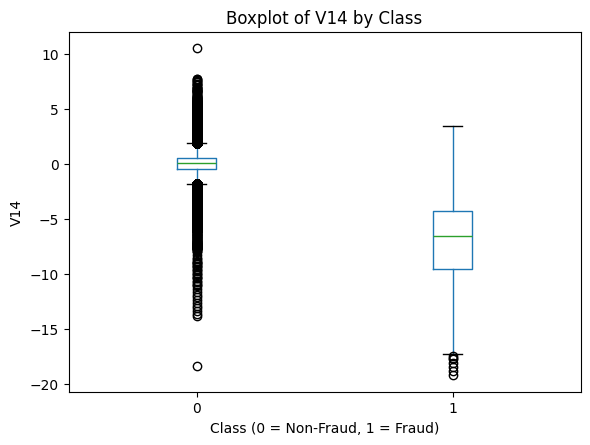

<Figure size 600x400 with 0 Axes>

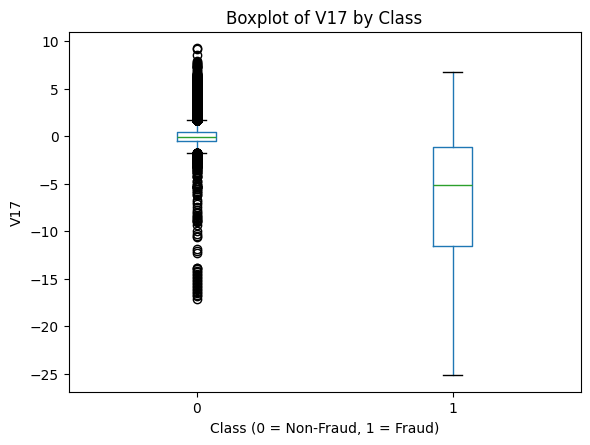

In [45]:

import matplotlib.pyplot as plt

# Features to inspect for outliers
selected_features = [
    'Amount',
    'V1', 'V2', 'V3', 'V4',
    'V10', 'V12', 'V14', 'V17'
]

# ------------------------------------------
# Boxplots by Class
# ------------------------------------------
for feature in selected_features:

    plt.figure(figsize=(6, 4))

    df.boxplot(
        column=feature,
        by='Class',
        grid=False
    )

    plt.title(f"Boxplot of {feature} by Class")
    plt.suptitle("")  # remove default title
    plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
    plt.ylabel(feature)
    plt.show()


In [46]:
# OPTIONAL: IQR-BASED OUTLIER COUNTS
# Count how many observations fall outside
# the 1.5 * IQR rule.

for feature in selected_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print(f"{feature}: {len(outliers)} outliers")



Amount: 31685 outliers
V1: 6948 outliers
V2: 13390 outliers
V3: 3306 outliers
V4: 11094 outliers
V10: 9345 outliers
V12: 15282 outliers
V14: 14060 outliers
V17: 7353 outliers


In [47]:
# OPTIONAL: OUTLIER COUNTS BY CLASS
for feature in selected_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print("\n" + "=" * 50)
    print(f"OUTLIERS IN {feature}")
    print("=" * 50)
    print(outliers['Class'].value_counts())


OUTLIERS IN Amount
Class
0    31598
1       87
Name: count, dtype: int64

OUTLIERS IN V1
Class
0    6790
1     158
Name: count, dtype: int64

OUTLIERS IN V2
Class
0    13160
1      230
Name: count, dtype: int64

OUTLIERS IN V3
Class
0    3013
1     293
Name: count, dtype: int64

OUTLIERS IN V4
Class
0    10794
1      300
Name: count, dtype: int64

OUTLIERS IN V10
Class
0    8965
1     380
Name: count, dtype: int64

OUTLIERS IN V12
Class
0    14892
1      390
Name: count, dtype: int64

OUTLIERS IN V14
Class
0    13649
1      411
Name: count, dtype: int64

OUTLIERS IN V17
Class
0    6974
1     379
Name: count, dtype: int64


# 8. DIMENSIONALITY REDUCTION VISUALIZATION


In [48]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# To keep t-SNE fast, use a sample
# Keep all fraud cases
fraud_df = df[df['Class'] == 1]

# Sample non-fraud cases
nonfraud_df = df[df['Class'] == 0].sample(
    n=2000,
    random_state=42
)

# Combine sampled data
sample_df = pd.concat([fraud_df, nonfraud_df])

print("Sample shape:", sample_df.shape)
print(sample_df['Class'].value_counts())


Sample shape: (2473, 33)
Class
0    2000
1     473
Name: count, dtype: int64


In [49]:
# Separate features and target
X_sample = sample_df.drop('Class', axis=1)
y_sample = sample_df['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)


Explained Variance Ratio:
[0.33258255 0.0822361 ]
Total Explained Variance: 0.41481865364695764


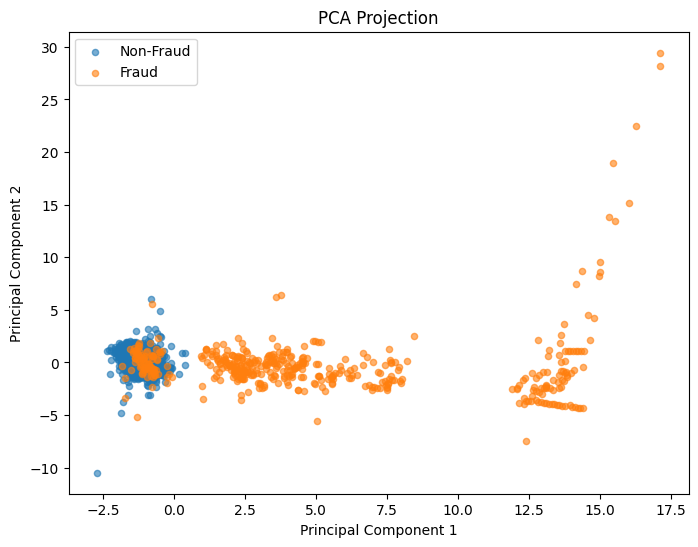

In [53]:
# 1. PCA TO 2 DIMENSIONS
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

# Plot PCA
plt.figure(figsize=(8, 6))

for cls, label in zip([0, 1], ['Non-Fraud', 'Fraud']):
    mask = y_sample == cls
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label,
        alpha=0.6,
        s=20
    )

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


# Interpretation
# Fraud points lie away from the main cluster, it means their feature values differ significantly from normal transactions.

# Limitation: PCA is linear, so it may not reveal complex nonlinear structure.

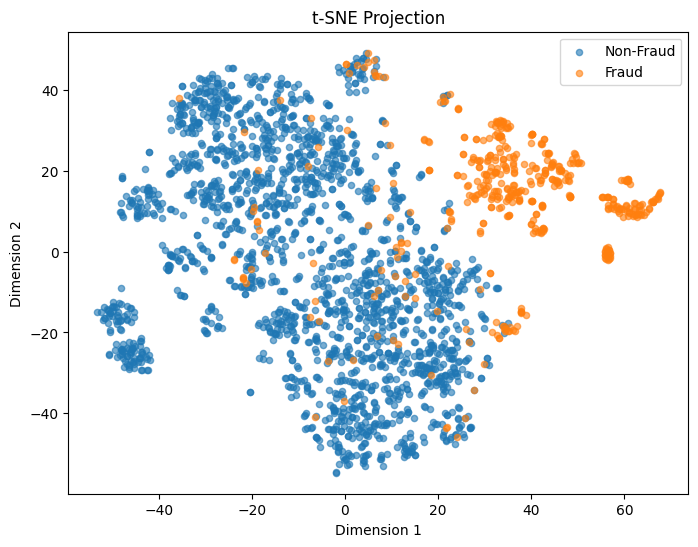

In [52]:
# 2. t-SNE TO 2 DIMENSIONS

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,      # use n_iter instead of max_iter
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE
plt.figure(figsize=(8, 6))

for cls, label in zip([0, 1], ['Non-Fraud', 'Fraud']):
    mask = y_sample == cls

    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=label,
        alpha=0.6,
        s=20
    )

plt.title("t-SNE Projection")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()


# Non-fraud points form several clusters.
# Fraud points often appear:
# As isolated clusters,
# In distinct pockets,
# Or at the boundaries of normal clusters.

